In [13]:
!pip install xgboost

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [38]:
file_path = "combined.csv"   
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   52    1                1         125.0        212.0                    0   
1   53    1                1         140.0        203.0                    1   
2   70    1                1         145.0        174.0                    0   
3   61    1                1         148.0        203.0                    0   
4   62    0                1         138.0        294.0                    1   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            1             168                0      1.0         2       0  
1            0             155                1      3.1         0       0  
2            1             125                1      2.6         0       0  
3            1             161                0      0.0         2       0  
4            1             106                0      1.9         1       0  

Shape of dataset:
(1220, 12)


In [39]:
df["ST slope"] = df["ST slope"].replace(0, np.nan)
df["ST slope"] = df["ST slope"].astype("string")

In [40]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1220 non-null   int64  
 1   sex                  1220 non-null   int64  
 2   chest pain type      1220 non-null   int64  
 3   resting bp s         1219 non-null   float64
 4   cholesterol          1048 non-null   float64
 5   fasting blood sugar  1220 non-null   int64  
 6   resting ecg          1220 non-null   int64  
 7   max heart rate       1220 non-null   int64  
 8   exercise angina      1220 non-null   int64  
 9   oldpeak              1220 non-null   float64
 10  ST slope             1198 non-null   string 
 11  target               1220 non-null   int64  
dtypes: float64(3), int64(8), string(1)
memory usage: 114.5 KB


In [41]:
X = df.drop("target", axis=1)
y = df["target"]

In [42]:
categorical_cols = [ 'sex', 'chest pain type', 'resting ecg', 'exercise angina', 'ST slope' ]

for col in categorical_cols:
    X[col] = X[col].astype("category")

In [43]:
print("Data types:")
print(X.dtypes)

print("\nMissing values per column:")
print(X.isna().sum())


Data types:
age                       int64
sex                    category
chest pain type        category
resting bp s            float64
cholesterol             float64
fasting blood sugar       int64
resting ecg            category
max heart rate            int64
exercise angina        category
oldpeak                 float64
ST slope               category
dtype: object

Missing values per column:
age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    enable_categorical=True
)

In [47]:
param_dist = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3, 5]
}

In [48]:
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

In [49]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [50]:
best_model = search.best_estimator_

print("\nBest Params:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)


Best Params:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}

Best CV Score:
0.843233203073351


In [51]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [52]:
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7909836065573771
Test F1: 0.8210526315789474
Test ROC-AUC: 0.8640568903617786

Confusion Matrix:
[[ 76  26]
 [ 25 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       102
           1       0.82      0.82      0.82       142

    accuracy                           0.79       244
   macro avg       0.79      0.78      0.78       244
weighted avg       0.79      0.79      0.79       244



In [53]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                feature  importance
10             ST slope    0.484613
2       chest pain type    0.101337
1                   sex    0.051844
4           cholesterol    0.051149
6           resting ecg    0.050335
9               oldpeak    0.049144
8       exercise angina    0.048740
5   fasting blood sugar    0.044978
3          resting bp s    0.040806
7        max heart rate    0.039311
0                   age    0.037743


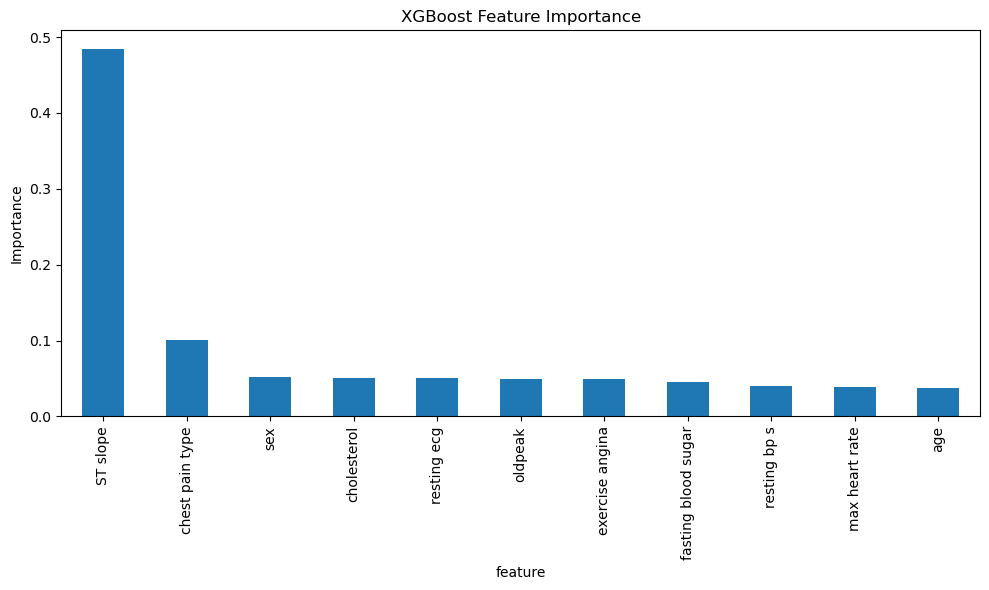

In [54]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("XGBoost Feature Importance.png", dpi=300)
plt.show()